# 02 - Modelado: preprocesamiento, baseline y evaluación

En este notebook se prepara el dataset de predicción de inundaciones para entrenamiento y se prueban varios modelos baseline de regresión para predecir `FloodProbability`.

El objetivo es cubrir una primera versión funcional del modelado, incluyendo métricas de regresión, comparación train/test, control de overfitting, análisis de residuos y guardado del modelo baseline seleccionado.

In [1]:
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

sns.set_theme(style="whitegrid")


## Carga del dataset

El notebook busca el archivo `train.csv` en varias rutas habituales para que pueda ejecutarse tanto en local como en Google Colab. En el repositorio, la ruta recomendada es `data/raw/train.csv`.

In [2]:
# Montaje opcional de Google Drive si el notebook se ejecuta en Colab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print("No se está ejecutando en Google Colab o no es necesario montar Drive.")


No se está ejecutando en Google Colab o no es necesario montar Drive.


In [9]:
from pathlib import Path
HERE = Path().resolve()
candidates = [
    HERE.parent / "data" / "raw" / "train.csv",
    HERE / "data" / "raw" / "train.csv",
    HERE / ".." / "data" / "raw" / "train.csv",
    HERE / "train.csv"
]
for c in candidates:
    if c.exists():
        DATA_PATH = c.resolve()
        break
else:
    raise FileNotFoundError("train.csv no encontrado")
print("Ruta utilizada:", DATA_PATH)

df = pd.read_csv(DATA_PATH)



Ruta utilizada: C:\Users\Personal\Proyecto-4--Grupo-1\data\raw\train.csv


## Preparación inicial

Se define la variable objetivo, se excluye la columna `id` porque es un identificador y se conservan las 20 variables predictoras relacionadas con factores de riesgo de inundación.

In [10]:
target = "FloodProbability"
feature_cols = [col for col in df.columns if col not in ["id", target]]

print("Variable objetivo:", target)
print("Número de variables predictoras:", len(feature_cols))
feature_cols


Variable objetivo: FloodProbability
Número de variables predictoras: 20


['MonsoonIntensity',
 'TopographyDrainage',
 'RiverManagement',
 'Deforestation',
 'Urbanization',
 'ClimateChange',
 'DamsQuality',
 'Siltation',
 'AgriculturalPractices',
 'Encroachments',
 'IneffectiveDisasterPreparedness',
 'DrainageSystems',
 'CoastalVulnerability',
 'Landslides',
 'Watersheds',
 'DeterioratingInfrastructure',
 'PopulationScore',
 'WetlandLoss',
 'InadequatePlanning',
 'PoliticalFactors']

In [ ]:
# Reducimos precisión en columnas float para optimizar memoria sin afectar de forma relevante al baseline.
cols_float = df.select_dtypes(include="float64").columns
df[cols_float] = df[cols_float].astype("float32")


## Separación de variables predictoras y variable objetivo

In [12]:
X = df[feature_cols]
y = df[target]

print("X:", X.shape)
print("y:", y.shape)


X: (1117957, 20)
y: (1117957,)


## Revisión de nulos

Aunque en el EDA no se detectaron valores nulos, se vuelve a comprobar antes del entrenamiento para evitar errores en los modelos.

In [13]:
print("Nulos en X:", X.isnull().sum().sum())
print("Nulos en y:", y.isnull().sum())

valid_index = X.dropna().index.intersection(y.dropna().index)
X = X.loc[valid_index]
y = y.loc[valid_index]

print("X final:", X.shape)
print("y final:", y.shape)


Nulos en X: 0
Nulos en y: 0
X final: (1117957, 20)
y final: (1117957,)


## Train/test split

Se reserva un 20% del dataset como conjunto de validación. Para acelerar el entrenamiento de los modelos baseline, se utiliza una muestra de 100.000 filas del conjunto de entrenamiento. Esta decisión permite comparar varios modelos de forma rápida y reproducible.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train,
    y_train,
    train_size=100000,
    random_state=42
)

print("Train completo:", X_train.shape)
print("Train muestra:", X_train_sample.shape)
print("Test:", X_test.shape)


Train completo: (894365, 20)
Train muestra: (100000, 20)
Test: (223592, 20)


## Funciones de evaluación

Se calculan RMSE, MAE y R2. Además, se compara R2 en entrenamiento y validación para medir el posible overfitting.

In [15]:
def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2


def evaluate_model(name, model, X_train_eval, y_train_eval, X_test_eval, y_test_eval):
    train_pred = model.predict(X_train_eval)
    test_pred = model.predict(X_test_eval)

    train_rmse, train_mae, train_r2 = regression_metrics(y_train_eval, train_pred)
    test_rmse, test_mae, test_r2 = regression_metrics(y_test_eval, test_pred)

    overfitting_r2_pct = abs(train_r2 - test_r2) / abs(train_r2) * 100 if train_r2 != 0 else np.nan

    return {
        "modelo": name,
        "RMSE_train": train_rmse,
        "MAE_train": train_mae,
        "R2_train": train_r2,
        "RMSE_test": test_rmse,
        "MAE_test": test_mae,
        "R2_test": test_r2,
        "overfitting_R2_%": overfitting_r2_pct,
        "cumple_overfitting": overfitting_r2_pct < 5,
        "train_pred": train_pred,
        "test_pred": test_pred,
    }


## Modelo 1: Linear Regression

In [16]:
lr = LinearRegression()
lr.fit(X_train_sample, y_train_sample)
res_lr = evaluate_model("Linear Regression", lr, X_train_sample, y_train_sample, X_test, y_test)

print(f"RMSE test: {res_lr['RMSE_test']:.4f}")
print(f"MAE test: {res_lr['MAE_test']:.4f}")
print(f"R2 test: {res_lr['R2_test']:.4f}")
print(f"Overfitting R2: {res_lr['overfitting_R2_%']:.2f}%")


RMSE test: 0.0201
MAE test: 0.0158
R2 test: 0.8449
Overfitting R2: 0.08%


## Modelo 2: Decision Tree

In [17]:
dt = DecisionTreeRegressor(max_depth=12, random_state=42)
dt.fit(X_train_sample, y_train_sample)
res_dt = evaluate_model("Decision Tree", dt, X_train_sample, y_train_sample, X_test, y_test)

print(f"RMSE test: {res_dt['RMSE_test']:.4f}")
print(f"MAE test: {res_dt['MAE_test']:.4f}")
print(f"R2 test: {res_dt['R2_test']:.4f}")
print(f"Overfitting R2: {res_dt['overfitting_R2_%']:.2f}%")


RMSE test: 0.0459
MAE test: 0.0367
R2 test: 0.1912
Overfitting R2: 62.32%


## Modelo 3: Random Forest básico

In [18]:
rf = RandomForestRegressor(
    n_estimators=20,
    max_depth=8,
    n_jobs=-1,
    random_state=42
)

inicio = time.time()
rf.fit(X_train_sample, y_train_sample)
print(f"Tiempo de entrenamiento: {time.time() - inicio:.1f} segundos")

res_rf = evaluate_model("Random Forest", rf, X_train_sample, y_train_sample, X_test, y_test)

print(f"RMSE test: {res_rf['RMSE_test']:.4f}")
print(f"MAE test: {res_rf['MAE_test']:.4f}")
print(f"R2 test: {res_rf['R2_test']:.4f}")
print(f"Overfitting R2: {res_rf['overfitting_R2_%']:.2f}%")


Tiempo de entrenamiento: 3.1 segundos
RMSE test: 0.0415
MAE test: 0.0337
R2 test: 0.3375
Overfitting R2: 11.56%


## Comparación de resultados

In [19]:
results = pd.DataFrame([
    {k: v for k, v in res_lr.items() if k not in ["train_pred", "test_pred"]},
    {k: v for k, v in res_dt.items() if k not in ["train_pred", "test_pred"]},
    {k: v for k, v in res_rf.items() if k not in ["train_pred", "test_pred"]},
])

results.sort_values("RMSE_test")


,modelo,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test,overfitting_R2_%,cumple_overfitting
0,Linear Regression,0.020072,0.015816,0.845510,0.020081,0.015803,0.844858,0.077131,True
2,Random Forest,0.040159,0.032624,0.381582,0.041498,0.033659,0.337464,11.561940,False
1,Decision Tree,0.035847,0.028440,0.507259,0.045852,0.036711,0.191156,62.315844,False


## Selección del modelo baseline

Se selecciona como baseline principal el modelo con menor RMSE en validación. En esta primera comparación, el modelo lineal suele ser una referencia fuerte porque el target parece depender de la combinación acumulada de muchas variables de riesgo.

In [20]:
best_row = results.sort_values("RMSE_test").iloc[0]
best_model_name = best_row["modelo"]

models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
}

predictions = {
    "Linear Regression": res_lr["test_pred"],
    "Decision Tree": res_dt["test_pred"],
    "Random Forest": res_rf["test_pred"],
}

best_model = models[best_model_name]
best_pred = predictions[best_model_name]

print("Mejor modelo baseline:", best_model_name)
best_row


Mejor modelo baseline: Linear Regression


modelo                Linear Regression
RMSE_train                     0.020072
MAE_train                      0.015816
R2_train                        0.84551
RMSE_test                      0.020081
MAE_test                       0.015803
R2_test                        0.844858
overfitting_R2_%               0.077131
cumple_overfitting                 True
Name: 0, dtype: object

## Predicción vs valor real

Este gráfico permite ver si las predicciones se acercan a la diagonal ideal. Cuanto más cerca estén los puntos de la línea roja, mejor será el ajuste del modelo.

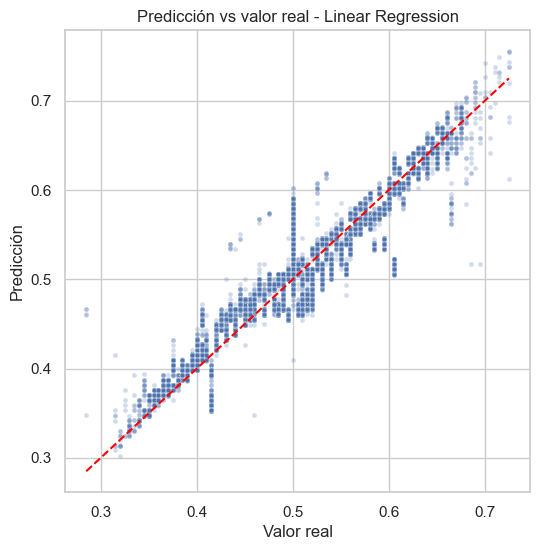

In [21]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=best_pred, alpha=0.25, s=12)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title(f"Predicción vs valor real - {best_model_name}")
plt.show()


## Análisis de residuos

Los residuos muestran la diferencia entre el valor real y la predicción. Una distribución centrada cerca de cero indica que el modelo no presenta un sesgo sistemático fuerte.

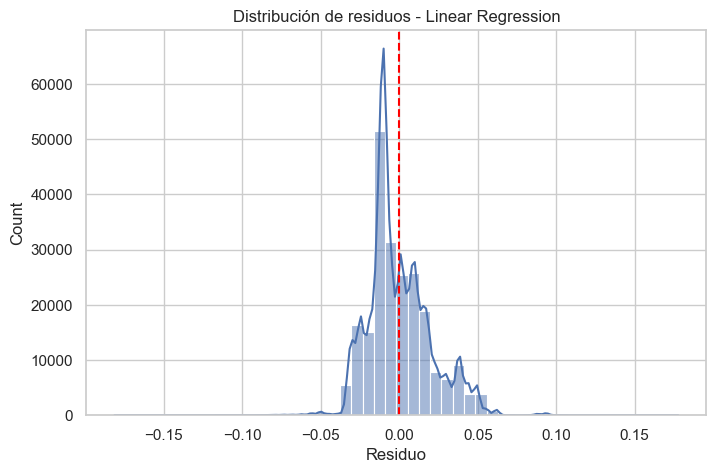

Media de residuos: -6.618356867499749e-05
Mediana de residuos: -0.004873640571373905
Desviación estándar de residuos: 0.020081204417996608


In [22]:
residuals = y_test - best_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residuo")
plt.title(f"Distribución de residuos - {best_model_name}")
plt.show()

print("Media de residuos:", residuals.mean())
print("Mediana de residuos:", residuals.median())
print("Desviación estándar de residuos:", residuals.std())


## Interpretabilidad del modelo

Para `Linear Regression`, se analizan los coeficientes del modelo. En modelos lineales, los coeficientes indican la dirección e intensidad aproximada de la relación entre cada variable predictora y la variable objetivo.

In [23]:
if best_model_name == "Linear Regression":
    importance = pd.DataFrame({
        "feature": feature_cols,
        "coefficient": best_model.coef_,
        "abs_coefficient": np.abs(best_model.coef_),
    }).sort_values("abs_coefficient", ascending=False)
else:
    importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": best_model.feature_importances_,
    }).sort_values("importance", ascending=False)

importance.head(10)


,feature,coefficient,abs_coefficient
17,WetlandLoss,0.005694,0.005694
6,DamsQuality,0.005687,0.005687
19,PoliticalFactors,0.005683,0.005683
4,Urbanization,0.005682,0.005682
12,CoastalVulnerability,0.005680,0.005680
3,Deforestation,0.005678,0.005678
11,DrainageSystems,0.005671,0.005671
9,Encroachments,0.005669,0.005669
16,PopulationScore,0.005665,0.005665
5,ClimateChange,0.005654,0.005654


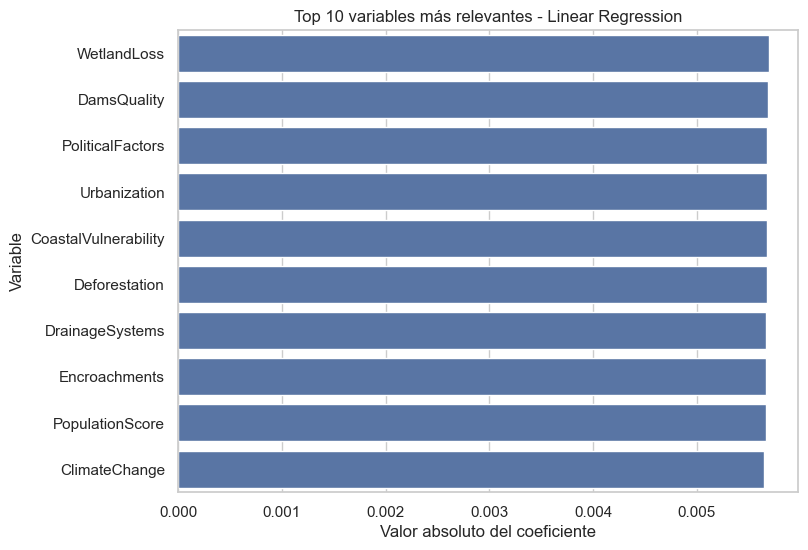

In [24]:
plt.figure(figsize=(8, 6))

if best_model_name == "Linear Regression":
    sns.barplot(data=importance.head(10), x="abs_coefficient", y="feature")
    plt.xlabel("Valor absoluto del coeficiente")
else:
    sns.barplot(data=importance.head(10), x="importance", y="feature")
    plt.xlabel("Importancia")

plt.ylabel("Variable")
plt.title(f"Top 10 variables más relevantes - {best_model_name}")
plt.show()


## Guardado del modelo baseline

Se guarda el modelo seleccionado para poder reutilizarlo posteriormente en la aplicación de Streamlit u otra solución de productivización.

In [25]:
models_dir = Path("../models")
if not models_dir.exists():
    models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "flood_baseline_model.joblib"
joblib.dump(best_model, model_path)

print(f"Modelo guardado en: {model_path.resolve()}")


Modelo guardado en: C:\Users\Personal\Proyecto-4--Grupo-1\models\flood_baseline_model.joblib


## Conclusiones del baseline

- Se entrenaron tres modelos iniciales: `Linear Regression`, `Decision Tree` y `Random Forest` básico.
- `Linear Regression` obtuvo el mejor rendimiento del baseline, con un RMSE de validación cercano a **0,020**, MAE cercano a **0,016** y R2 cercano a **0,845**.
- La comparación entre entrenamiento y validación permite comprobar el overfitting. El modelo lineal mantiene una diferencia inferior al 5%, por lo que cumple el requisito esencial de generalización en esta primera versión.
- Los modelos basados en árboles rindieron peor con la configuración simplificada utilizada. Esto no descarta su utilidad, pero indica que necesitarían más ajuste de hiperparámetros o modelos ensemble más potentes para competir con el baseline lineal.
- El análisis de predicción vs valor real y residuos permite evaluar visualmente el comportamiento del modelo seleccionado.
- Los coeficientes del modelo lineal aportan una primera interpretación de qué variables tienen mayor peso en la predicción.
- El modelo baseline seleccionado se ha guardado para poder reutilizarlo en la futura aplicación.

El siguiente paso será mejorar el modelo con validación cruzada, optimización de hiperparámetros y/o modelos más avanzados, además de preparar la app de productivización.